<a href="https://colab.research.google.com/github/Chathu283/Statistical-Learning-e23218/blob/main/kalman_filter_assignment_Answers.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Q1. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

# Question 1 Answers

## (1) Show that

$$
x_k^- \sim \mathcal{N}(m_k^-,P_k^-)
$$

Given the prediction model,

$$
x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1},
$$

where

$$
x_{k-1}^+ \sim \mathcal{N}(m_{k-1},P_{k-1}),
$$

and

$$
w_{k-1}\sim\mathcal{N}(0,\Sigma_p),
$$

with the process noise independent of the previous state estimate.

Since a linear transformation of a Gaussian random vector is also Gaussian,

$$
x_k^- \sim \mathcal{N}\left(
A_{k-1}m_{k-1},
A_{k-1}P_{k-1}A_{k-1}^{T}
+
G_{k-1}\Sigma_pG_{k-1}^{T}
\right).
$$

Therefore, the predicted mean is

$$
m_k^- = A_{k-1}m_{k-1},
$$

and the predicted covariance is

$$
P_k^-=
A_{k-1}P_{k-1}A_{k-1}^{T}
+
G_{k-1}\Sigma_pG_{k-1}^{T}.
$$

Hence,

$$
\boxed{
x_k^- \sim
\mathcal{N}(m_k^-,P_k^-)
}
$$

---

## (2) Show that

$$
y_k^- \sim
\mathcal{N}
\left(
H_km_k^-,
H_kP_k^-H_k^T+\Sigma_m
\right)
$$

The measurement model is

$$
y_k^- = H_kx_k^- + z_k,
$$

where

$$
z_k\sim\mathcal{N}(0,\Sigma_m).
$$

The expected value is

$$
\begin{aligned}
E[y_k^-]
&=
E[H_kx_k^-+z_k] \\
&=
H_kE[x_k^-]+E[z_k] \\
&=
H_km_k^-.
\end{aligned}
$$

The covariance is

$$
\begin{aligned}
Var(y_k^-)
&=
Var(H_kx_k^-+z_k) \\
&=
H_kP_k^-H_k^T+\Sigma_m.
\end{aligned}
$$

Therefore,

$$
\boxed{
y_k^- \sim
\mathcal{N}
\left(
H_km_k^-,
H_kP_k^-H_k^T+\Sigma_m
\right)
}
$$

---

## (3) Derive the joint Gaussian distribution

Since

$$
y_k^- = H_kx_k^- + z_k,
$$

the joint mean vector is

$$
\mu=
\begin{bmatrix}
m_k^- \\
H_km_k^-
\end{bmatrix}.
$$

The covariance matrix consists of four blocks.

State covariance:

$$
Var(x_k^-)=P_k^-.
$$

Cross covariance:

$$
\begin{aligned}
Cov(x_k^-,y_k^-)
&=
Cov(x_k^-,H_kx_k^-+z_k) \\
&=
P_k^-H_k^T.
\end{aligned}
$$

Similarly,

$$
Cov(y_k^-,x_k^-)
=
H_kP_k^-.
$$

Measurement covariance:

$$
Var(y_k^-)
=
H_kP_k^-H_k^T+\Sigma_m.
$$

Hence,

$$
\boxed{
\begin{bmatrix}
x_k^-\\
y_k^-
\end{bmatrix}
\sim
\mathcal{N}
\left(
\begin{bmatrix}
m_k^-\\
H_km_k^-
\end{bmatrix},
\begin{bmatrix}
P_k^- & P_k^-H_k^T\\
H_kP_k^- & H_kP_k^-H_k^T+\Sigma_m
\end{bmatrix}
\right)
}
$$

---

## (4) Show that the posterior distribution is Gaussian

For jointly Gaussian random variables, conditioning also produces a Gaussian distribution.

Thus,

$$
x_k^+
=
(x_k^-|y_k=y_k^{obs})
\sim
\mathcal{N}(m_k,P_k).
$$

The Kalman gain is

$$
K_k
=
P_k^-H_k^T
\left(
H_kP_k^-H_k^T+\Sigma_m
\right)^{-1}.
$$

The posterior mean is

$$
m_k
=
m_k^-
+
K_k
\left(
y_k^{obs}
-
H_km_k^-
\right).
$$

The posterior covariance becomes

$$
P_k
=
(I-K_kH_k)P_k^-.
$$

Therefore,

$$
\boxed{
x_k^+
\sim
\mathcal{N}(m_k,P_k)
}
$$

---

## (5) Conditional expectation and conditional variance

The conditional expectation is simply the posterior mean,

$$
\boxed{
E[x_k^-|y_k=y_k^{obs}]
=
m_k^-+
K_k
(y_k^{obs}-H_km_k^-)
}
$$

where

$$
K_k
=
P_k^-H_k^T
(H_kP_k^-H_k^T+\Sigma_m)^{-1}.
$$

The conditional variance is

$$
\boxed{
Var(x_k^-|y_k=y_k^{obs})
=
(I-K_kH_k)P_k^-.
}
$$

These equations represent the Kalman Filter update equations for the posterior state estimate and its uncertainty.

# Q2. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

# Question 2 Answers

Consider the one-dimensional state-space model

$$
x_k=ax_{k-1}+w_{k-1},
$$

where

$$
w_{k-1}\sim\mathcal N(0,q),
$$

and the measurement model

$$
y_k=hx_k+z_k,
$$

where

$$
z_k\sim\mathcal N(0,r).
$$

Assume

$$
x_{k-1}\sim\mathcal N(m_{k-1},P_{k-1}).
$$

---

## (1) Derive the prediction equations

The state prediction equation is

$$
x_k^-=ax_{k-1}+w_{k-1}.
$$

Since the expectation of the process noise is zero,

$$
E[w_{k-1}]=0,
$$

the predicted mean becomes

$$
\begin{aligned}
m_k^-
&=E[x_k^-] \\
&=E[ax_{k-1}+w_{k-1}] \\
&=aE[x_{k-1}] \\
&=am_{k-1}.
\end{aligned}
$$

Therefore,

$$
\boxed{
m_k^-=am_{k-1}
}
$$

Next, compute the covariance.

Since the process noise is independent of the previous state,

$$
\begin{aligned}
P_k^-
&=Var(ax_{k-1}+w_{k-1}) \\
&=a^2Var(x_{k-1})+Var(w_{k-1}) \\
&=a^2P_{k-1}+q.
\end{aligned}
$$

Hence,

$$
\boxed{
P_k^-=a^2P_{k-1}+q.
}
$$

---

## (2) Derive the Kalman update equations

The innovation (measurement residual) is

$$
v_k
=
y_k^{obs}-hm_k^-.
$$

The innovation covariance is

$$
\boxed{
S_k
=
h^2P_k^-+r.
}
$$

The Kalman gain is

$$
\boxed{
K_k
=
\frac{P_k^-h}{S_k}
=
\frac{P_k^-h}
{h^2P_k^-+r}.
}
$$

The posterior mean estimate is

$$
\begin{aligned}
m_k
&=
m_k^-+K_kv_k \\
&=
m_k^-+
K_k(y_k^{obs}-hm_k^-).
\end{aligned}
$$

Substituting the Kalman gain,

$$
\boxed{
m_k
=
m_k^-+
\frac{P_k^-h}
{h^2P_k^-+r}
(y_k^{obs}-hm_k^-).
}
$$

The posterior covariance becomes

$$
\boxed{
P_k=(1-K_kh)P_k^-.
}
$$

These equations complete the Kalman Filter correction step.

---

## (3) Find the predictive measurement distribution

The measurement equation is

$$
y_k=hx_k^-+z_k.
$$

Since

$$
x_k^-
\sim
\mathcal N(m_k^-,P_k^-),
$$

and

$$
z_k
\sim
\mathcal N(0,r),
$$

the measurement prediction is also Gaussian.

The expected value is

$$
\begin{aligned}
E[y_k]
&=
E[hx_k^-+z_k] \\
&=
hm_k^-.
\end{aligned}
$$

The variance is

$$
\begin{aligned}
Var(y_k)
&=
Var(hx_k^-+z_k) \\
&=
h^2P_k^-+r.
\end{aligned}
$$

Hence,

$$
\boxed{
p(y_k|Y_{k-1})
=
\mathcal N
\left(
hm_k^-,
h^2P_k^-+r
\right).
}
$$

This distribution represents the predicted probability of the next measurement before incorporating the current observation.

---

## (4) Find the posterior measurement distribution

After incorporating the measurement,

$$
x_k
\sim
\mathcal N(m_k,P_k).
$$

Using the measurement equation,

$$
y_k=hx_k+z_k,
$$

the expected value becomes

$$
E[y_k|Y_k]
=
hm_k,
$$

while the variance becomes

$$
Var(y_k|Y_k)
=
h^2P_k+r.
$$

Therefore,

$$
\boxed{
p(y_k|Y_k)
=
\mathcal N
\left(
hm_k,
h^2P_k+r
\right).
}
$$

This distribution represents the uncertainty of future measurements after the state estimate has been updated.

---

## (5) Interpretation

The Kalman Filter consists of two stages:

### Prediction Step

The previous state estimate is propagated through the system dynamics to predict the current state.

The prediction equations are

$$
m_k^-=am_{k-1},
$$

and

$$
P_k^-=a^2P_{k-1}+q.
$$

The process noise covariance $q$ increases the uncertainty because the system dynamics are not perfectly known.

---

### Update Step

When a new measurement becomes available, the prediction is corrected.

The innovation is

$$
v_k=y_k^{obs}-hm_k^-,
$$

which measures the discrepancy between the predicted and observed measurements.

The Kalman gain,

$$
K_k=
\frac{P_k^-h}
{h^2P_k^-+r},
$$

determines how much the estimate should trust the measurement versus the model prediction.

A larger measurement noise variance $r$ results in a smaller Kalman gain, meaning the filter relies more heavily on the prediction. Conversely, a smaller value of $r$ increases the Kalman gain, placing greater confidence in the measurement.

Finally, the updated covariance

$$
P_k=(1-K_kh)P_k^-,
$$

is always smaller than the predicted covariance, demonstrating that incorporating a measurement reduces the uncertainty of the state estimate.

# Q3. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

# Question 3 Answers – 2D Position Estimation

## Part a: Derive the discrete-time state-space model

Consider an object moving in a two-dimensional plane with a **constant velocity**. Let the state vector be defined as

$$
x_k=
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where

- $p_x(k)$ and $p_y(k)$ are the position coordinates,
- $v_x(k)$ and $v_y(k)$ are the velocity components.

Assume that the sampling interval is

$$
\Delta t.
$$

---

### Position Update

From the equation of motion,

$$
\text{Position}
=
\text{Initial Position}
+
\text{Velocity}\times\Delta t,
$$

the x-direction becomes

$$
p_x(k)
=
p_x(k-1)
+
v_x(k-1)\Delta t.
$$

Similarly,

$$
p_y(k)
=
p_y(k-1)
+
v_y(k-1)\Delta t.
$$

---

### Velocity Update

Since the model assumes constant velocity,

$$
v_x(k)=v_x(k-1),
$$

and

$$
v_y(k)=v_y(k-1).
$$

---

Combining all four equations,

$$
\begin{aligned}
p_x(k)
&=
p_x(k-1)+v_x(k-1)\Delta t,\\
p_y(k)
&=
p_y(k-1)+v_y(k-1)\Delta t,\\
v_x(k)
&=
v_x(k-1),\\
v_y(k)
&=
v_y(k-1).
\end{aligned}
$$

These equations can be written in matrix form as

$$
x_k
=
Ax_{k-1},
$$

where

$$
\boxed{
A=
\begin{bmatrix}
1&0&\Delta t&0\\
0&1&0&\Delta t\\
0&0&1&0\\
0&0&0&1
\end{bmatrix}
}
$$

This matrix is called the **state transition matrix** because it propagates the state from one time step to the next.

---

## Process Noise

In practice, the object does not move with perfectly constant velocity.

Small unknown accelerations occur because of

- steering,
- braking,
- road irregularities,
- wind disturbances,
- modelling errors.

These effects are represented by the process noise

$$
w_k=
\begin{bmatrix}
a_x\\
a_y
\end{bmatrix},
$$

where

$$
w_k
\sim
\mathcal N(0,Q).
$$

---

### Effect of Acceleration

Using elementary kinematics,

Position change due to acceleration is

$$
\Delta p
=
\frac12a\Delta t^2,
$$

while velocity changes by

$$
\Delta v
=
a\Delta t.
$$

Therefore the process noise enters the state equation through

$$
Gw_k,
$$

where

$$
\boxed{
G=
\begin{bmatrix}
\frac12\Delta t^2&0\\
0&\frac12\Delta t^2\\
\Delta t&0\\
0&\Delta t
\end{bmatrix}
}
$$

Thus the complete state equation becomes

$$
\boxed{
x_k
=
Ax_{k-1}
+
Gw_k.
}
$$

---

## Measurement Model

Assume that the GPS sensor measures only the object's position.

The measurement vector is

$$
y_k=
\begin{bmatrix}
p_x(k)\\
p_y(k)
\end{bmatrix}.
$$

Since velocity is not measured,

the measurement equation becomes

$$
y_k
=
Hx_k
+
z_k,
$$

where

$$
z_k
\sim
\mathcal N(0,R)
$$

is the measurement noise.

The observation matrix is therefore

$$
\boxed{
H=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0
\end{bmatrix}.
}
$$

---

## Final State-Space Model

The complete discrete-time model is

$$
\boxed{
x_k
=
Ax_{k-1}
+
Gw_k,
}
$$

where

$$
A=
\begin{bmatrix}
1&0&\Delta t&0\\
0&1&0&\Delta t\\
0&0&1&0\\
0&0&0&1
\end{bmatrix},
$$

$$
G=
\begin{bmatrix}
\frac12\Delta t^2&0\\
0&\frac12\Delta t^2\\
\Delta t&0\\
0&\Delta t
\end{bmatrix},
$$

and

$$
w_k
\sim
\mathcal N(0,Q).
$$

The measurement equation is

$$
\boxed{
y_k
=
Hx_k
+
z_k,
}
$$

where

$$
H=
\begin{bmatrix}
1&0&0&0\\
0&1&0&0
\end{bmatrix},
$$

and

$$
z_k
\sim
\mathcal N(0,R).
$$

---

## Interpretation

The state transition matrix $A$ predicts the next position and velocity based on the constant velocity assumption.

The process noise matrix $G$ incorporates unknown accelerations into the system dynamics, allowing the filter to model deviations from perfect constant velocity.

The observation matrix $H$ extracts only the position components from the state vector because the GPS sensor measures position but not velocity.

This state-space formulation is the standard constant-velocity model used in two-dimensional Kalman filtering and provides the foundation for recursively estimating the position and velocity of a moving object.

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

##Answer

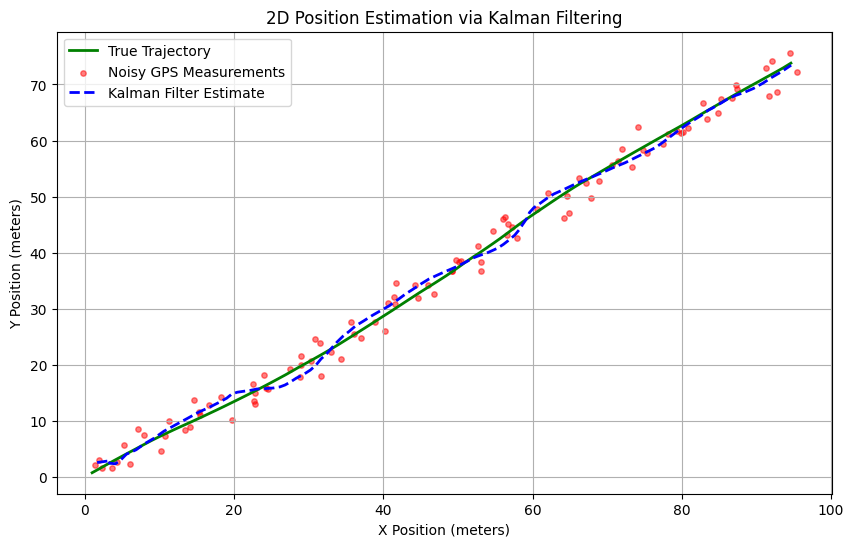

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Parameter Definitions
dt = 0.5  # Time step delta_t
num_steps = 100  # Total simulation steps

# Process noise covariance (for acceleration variations)
sigma_p_sq = 0.1**2
Sigma_p = np.array([
    [sigma_p_sq, 0],
    [0, sigma_p_sq]
])

# Measurement noise covariance (GPS uncertainty)
sigma_m_sq = 1.5**2
Sigma_m = np.array([
    [sigma_m_sq, 0],
    [0, sigma_m_sq]
])

# 2. System Matrix Formulations (from Part A)
A = np.array([
    [1, 0, dt,  0],
    [0, 1,  0, dt],
    [0, 0,  1,  0],
    [0, 0,  0,  1]
])

H = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0]
])

G = np.array([
    [0.5 * dt**2,           0],
    [          0, 0.5 * dt**2],
    [         dt,           0],
    [          0,          dt]
])

# Calculate total process noise covariance Q = G * Sigma_p * G^T
Q = G @ Sigma_p @ G.T
# Measurement noise covariance R = Sigma_m
R = Sigma_m

# 3. Generate Synthetic Data (True trajectory and Noisy GPS Measurements)
np.random.seed(42)  # For reproducibility

# True initial state: [px, py, vx, vy]
true_x = np.array([0.0, 0.0, 2.0, 1.5])

true_states = []
measurements = []

for k in range(num_steps):
    # Generate process noise
    w = np.random.multivariate_normal(np.zeros(2), Sigma_p)
    # State transition: x_k = A * x_{k-1} + G * w_{k-1}
    true_x = A @ true_x + G @ w
    true_states.append(true_x)

    # Generate measurement noise
    z = np.random.multivariate_normal(np.zeros(2), Sigma_m)
    # Measurement: y_k = H * x_k + z_k
    y = H @ true_x + z
    measurements.append(y)

true_states = np.array(true_states)
measurements = np.array(measurements)

# 4. Kalman Filter Implementation
# Initial guesses
m = np.array([0.0, 0.0, 0.0, 0.0])  # Initial mean state estimate
P = np.eye(4) * 10.0                # Initial highly uncertain covariance estimate

estimated_states = []

for k in range(num_steps):
    # --- PREDICT STEP ---
    m_minus = A @ m
    P_minus = A @ P @ A.T + Q

    # --- UPDATE STEP ---
    y_obs = measurements[k]

    # Innovation covariance
    S = H @ P_minus @ H.T + R

    # Kalman Gain
    K = P_minus @ H.T @ np.linalg.inv(S)

    # Update state mean and covariance
    m = m_minus + K @ (y_obs - H @ m_minus)
    P = (np.eye(4) - K @ H) @ P

    estimated_states.append(m)

estimated_states = np.array(estimated_states)

# 5. Visualization
plt.figure(figsize=(10, 6))
plt.plot(true_states[:, 0], true_states[:, 1], 'g-', label='True Trajectory', linewidth=2)
plt.scatter(measurements[:, 0], measurements[:, 1], color='red', alpha=0.5, s=15, label='Noisy GPS Measurements')
plt.plot(estimated_states[:, 0], estimated_states[:, 1], 'b--', label='Kalman Filter Estimate', linewidth=2)
plt.title('2D Position Estimation via Kalman Filtering')
plt.xlabel('X Position (meters)')
plt.ylabel('Y Position (meters)')
plt.legend()
plt.grid(True)
plt.show()

#Explanation of the Implementation:

###System Matrices:
We explicitly built $A$, $H$, and $G$ using the system equations you solved for in Part A. The process noise entering the state equations becomes

$$
Q = G \Sigma_p G^T
$$


###Data Simulation:
We simulated a realistic ground truth path with continuous velocity and added Gaussian white noise to emulate standard GPS measurement error.

###Predict and Update Loop:
At each time step, the code executes the fundamental operations of the Kalman Filter: it forecasts the next location mathematically, then corrects that forecast using incoming measurements relative to the sensor confidence ($K_k$).